In [1]:
%matplotlib inline

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import ovrlpy
import polars as pl
import seaborn as sns
from matplotlib_scalebar.scalebar import ScaleBar
from scipy.sparse import coo_array

data_folder_path = Path(
    "/dh-projects/ag-ishaque/raw_data/tiesmeys-ovrlpy/Xenium-brain-2024/replicate1"
)

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys

import matplotlib

sys.path.append("../..")

from ovrlpy._plotting import BIH_CMAP as cmap
from ovrlpy._plotting import _plot_signal_integrity

from utils import CM, FONT, save_kwargs

matplotlib.rc("font", **FONT)

In [4]:
transcripts = ovrlpy.io.read_Xenium(
    data_folder_path / "transcripts.parquet",
    additional_columns=["overlaps_nucleus", "cell_id"],
)

# z reorientation

In [5]:
gridsize = 5

pixel_elevation = (
    transcripts.lazy()
    .with_columns(pl.col(x).floordiv(gridsize).cast(int) for x in ["x", "y"])
    .group_by(["x", "y"])
    .agg(pl.col("z").mean())
    .collect()
)

mean_elevation = coo_array(
    (
        pixel_elevation["z"].to_numpy(),
        (pixel_elevation["x"].to_numpy(), pixel_elevation["y"].to_numpy()),
    )
).toarray()

mean_elevation[mean_elevation == 0] = np.nan

In [6]:
z_range = (np.nanmin(mean_elevation), np.nanmax(mean_elevation))
z_range

(4.258126, 32.211086)

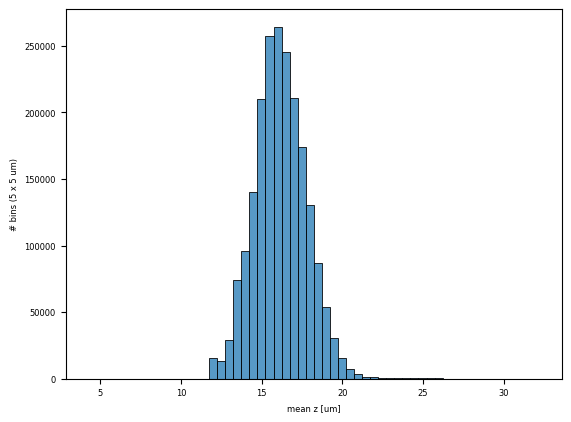

In [7]:
ax = sns.histplot(mean_elevation[~np.isnan(mean_elevation)], binwidth=0.5)
_ = ax.set(xlabel="mean z [um]", ylabel=f"# bins ({gridsize} x {gridsize} um)")

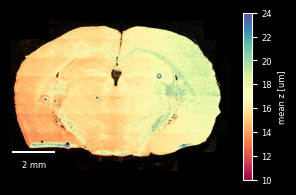

In [8]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(9 * CM, 5.5 * CM))
    im = ax.imshow(mean_elevation.T, cmap="Spectral", origin="lower", vmin=10, vmax=24)
    plt.colorbar(im, label="mean z [um]")
    ax.set_axis_off()
    ax.add_artist(ScaleBar(5, units="um", frameon=False, color="w", loc="lower left"))

    fig.savefig("global_z.svg", **save_kwargs)

In [9]:
def pixel_gene_count(df, gridsize, coord=["x", "y"]):
    pixelcount = (
        df.with_columns(pl.col(x).floordiv(gridsize).cast(int) for x in coord)
        .group_by(coord)
        .len(name="count")
    )
    return count_df_to_arr(pixelcount, coord)


def count_df_to_arr(df, coord=["x", "y"]):
    count = (
        coo_array(
            (df["count"].to_numpy(), (df[coord[0]].to_numpy(), df[coord[1]].to_numpy()))
        )
        .toarray()
        .astype(float)
    )
    count[count == 0] = np.nan
    return count


naive_threshold = np.nanmean(mean_elevation)

top_count = pixel_gene_count(
    transcripts.filter(pl.col("z") > naive_threshold), gridsize
)
bottom_count = pixel_gene_count(
    transcripts.filter(pl.col("z") < naive_threshold), gridsize
)

In [10]:
transcripts = ovrlpy.process_coordinates(transcripts)

top_count_virtual = pixel_gene_count(
    transcripts.filter(pl.col("z") > pl.col("z_center")), gridsize
)
bottom_count_virtual = pixel_gene_count(
    transcripts.filter(pl.col("z") < pl.col("z_center")), gridsize
)

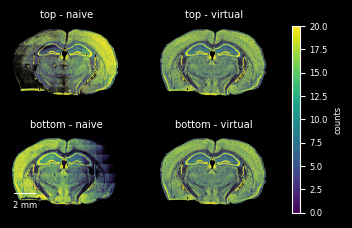

In [11]:
def plot_counts(arr, ax, title):
    im = ax.imshow(arr.T, cmap="viridis", origin="lower", vmin=0, vmax=20)
    ax.set_axis_off()
    ax.set_title(title)
    return im


with plt.style.context("dark_background"):
    fig = plt.figure(figsize=(9 * CM, 5.5 * CM), constrained_layout=True)
    gs = fig.add_gridspec(nrows=2, ncols=3, width_ratios=[19, 19, 1])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[0, 1])
    ax4 = fig.add_subplot(gs[1, 1])
    cax = fig.add_subplot(gs[:, -1])

    _ = plot_counts(top_count, ax1, "top - naive")
    im = plot_counts(bottom_count, ax2, "bottom - naive")
    _ = plot_counts(top_count_virtual, ax3, "top - virtual")
    _ = plot_counts(bottom_count_virtual, ax4, "bottom - virtual")
    fig.colorbar(im, cax=cax, label="counts")
    ax2.add_artist(
        ScaleBar(gridsize, units="um", frameon=False, color="w", loc="lower left")
    )
    fig.savefig("slicing_strategies.svg", **save_kwargs)

## z-reorientation vs gridsize

In [12]:
from ovrlpy._subslicing import _assign_xy, _mean_elevation, _message_passing

elevations = {}
for gridsize in [1, 2, 5, 10]:
    elevation = _mean_elevation(
        _assign_xy(transcripts, gridsize=gridsize, shift=False), "z", dtype=pl.Float32
    )
    elevations[gridsize] = _message_passing(elevation, n_iter=20)

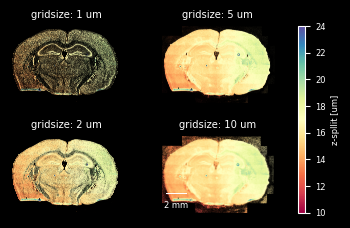

In [13]:
def plot_z(arr, ax, title):
    im = ax.imshow(arr.T, cmap="Spectral", origin="lower", vmin=10, vmax=24)
    ax.set_axis_off()
    ax.set_title(title)
    return im


with plt.style.context("dark_background"):
    fig = plt.figure(figsize=(9 * CM, 5.5 * CM), constrained_layout=True)
    gs = fig.add_gridspec(nrows=2, ncols=3, width_ratios=[19, 19, 1])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[0, 1])
    ax4 = fig.add_subplot(gs[1, 1])
    cax = fig.add_subplot(gs[:, -1])

    for (size, elevation), ax in zip(elevations.items(), [ax1, ax2, ax3, ax4]):
        im = plot_z(elevation, ax, f"gridsize: {size} um")
    fig.colorbar(im, cax=cax, label="z-spllit [um]")
    ax4.add_artist(
        ScaleBar(size, units="um", frameon=False, color="w", loc="lower left")
    )

    fig.savefig("grid_sizes.svg", **save_kwargs)

# Virtual subslices

In [14]:
import pickle

with open("../xenium_brain.pickle", "rb") as file:
    brain = pickle.load(file)

In [15]:
transcripts = ovrlpy.process_coordinates(transcripts)

transcripts_bottom = transcripts.filter(pl.col("z") < pl.col("z_center")).select(
    ["gene", "x", "y", "z"]
)

transcripts_top = transcripts.filter(pl.col("z") > pl.col("z_center")).select(
    ["gene", "x", "y", "z"]
)

In [16]:
brain_bottom = ovrlpy.Ovrlp(transcripts_bottom, n_workers=16, random_state=42)

brain_bottom.process_coordinates(shift=False)
brain_bottom.fit_transcripts(min_transcripts=20, fit_umap=False)
brain_bottom.compute_VSI()

determining pseudocells
found 58224 pseudocells
sampling expression:


100%|██████████| 315/315 [04:42<00:00,  1.11it/s]


In [17]:
import pickle

with open("bottom_subslice.pickle", "wb") as file:
    pickle.dump(brain_bottom, file)

In [18]:
brain_top = ovrlpy.Ovrlp(transcripts_top, n_workers=16, random_state=42)

brain_top.process_coordinates(shift=False)
brain_top.fit_transcripts(min_transcripts=20, fit_umap=False)
brain_top.compute_VSI()

determining pseudocells
found 59315 pseudocells
sampling expression:


100%|██████████| 315/315 [04:39<00:00,  1.13it/s]


In [19]:
import pickle

with open("top_subslice.pickle", "wb") as file:
    pickle.dump(brain_bottom, file)

In [4]:
import pickle

with open("bottom_subslice.pickle", "rb") as file:
    brain_bottom = pickle.load(file)

with open("top_subslice.pickle", "rb") as file:
    brain_top = pickle.load(file)

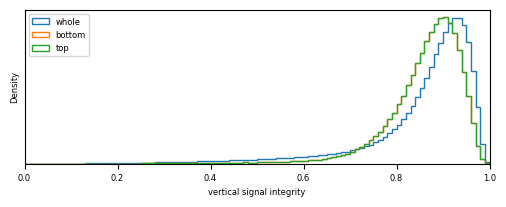

In [35]:
t = 2

xlim = (0, 1)
kwargs = dict(bins=100, range=xlim, density=True, histtype="step")

fig, ax = plt.subplots(figsize=(6, 2))
ax.hist(brain.integrity_map[brain.signal_map > t], label="whole", **kwargs)
ax.hist(
    brain_bottom.integrity_map[brain_bottom.signal_map > t], label="bottom", **kwargs
)
ax.hist(brain_top.integrity_map[brain_top.signal_map > t], label="top", **kwargs)
_ = ax.set(ylabel="Density", yticks=[], xlabel="vertical signal integrity", xlim=xlim)
_ = ax.legend()

## Compare SubSlice vs Slice

In [24]:
brain_sub = ovrlpy.Ovrlp(
    # downsample to same number of transcripts as bottom slice
    transcripts.sample(transcripts_bottom.shape[0], seed=42),
    n_workers=16,
    random_state=42,
)
brain_sub.process_coordinates(shift=False)
brain_sub.fit_transcripts(min_transcripts=20, fit_umap=False)
brain_sub.compute_VSI()

determining pseudocells
found 59325 pseudocells
sampling expression:


100%|██████████| 315/315 [04:51<00:00,  1.08it/s]


In [25]:
import pickle

with open("whole_downsampled.pickle", "wb") as file:
    pickle.dump(brain_sub, file)

In [26]:
brain_top = ovrlpy.Ovrlp(
    # downsample to same number of transcripts as bottom slice
    transcripts_top.sample(transcripts_bottom.shape[0], seed=42),
    n_workers=16,
    random_state=42,
)
brain_top.process_coordinates(shift=False)
brain_top.fit_transcripts(min_transcripts=20, fit_umap=False)
brain_top.compute_VSI()

determining pseudocells
found 59431 pseudocells
sampling expression:


100%|██████████| 315/315 [04:59<00:00,  1.05it/s]


In [27]:
import pickle

with open("top_downsampled.pickle", "wb") as file:
    pickle.dump(brain_top, file)

In [5]:
import pickle

with open("whole_downsampled.pickle", "rb") as file:
    brain_sub = pickle.load(file)

with open("top_downsampled.pickle", "rb") as file:
    brain_top = pickle.load(file)

In [6]:
doublets = brain_sub.detect_doublets(min_signal=3, integrity_sigma=2)

In [7]:
def plot_vsi(ovrlp, ax, *, threshold=2):
    img = _plot_signal_integrity(ax, ovrlp.integrity_map, ovrlp.signal_map, threshold)
    ax.set(xticks=[], yticks=[], aspect="equal")
    return img

In [8]:
t = 1.5

scalebar_kwargs = dict(dx=1, units="um", loc="lower left", frameon=False, color="w")

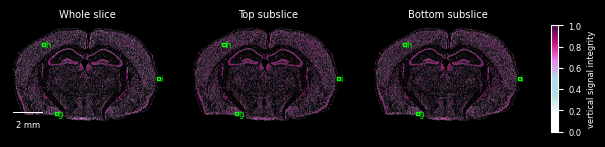

In [52]:
labels = "ghi"

with plt.style.context("dark_background"):
    fig, axs = plt.subplots(
        ncols=4, figsize=(18 * CM, 3.5 * CM), width_ratios=[6, 6, 6, 0.3]
    )

    _ = plot_vsi(brain_sub, axs[0], threshold=t)
    _ = plot_vsi(brain_top, axs[1], threshold=t)
    img = plot_vsi(brain_bottom, axs[2], threshold=t)

    for ax in axs[:3]:
        ax.set_axis_off()

    axs[0].add_artist(ScaleBar(**scalebar_kwargs))

    axs[0].set_title("Whole slice")
    axs[1].set_title("Top subslice")
    axs[2].set_title("Bottom subslice")

    _ = fig.colorbar(img, cax=axs[3], label="vertical signal integrity")

    for l, i in zip(labels, range(3)):
        x, y = doublets["x", "y"].row(i)
        for ax in axs[:3]:
            ax.text(x + 100, y, l, color="lime", fontsize=6, va="center")
            ax.scatter(
                x, y, marker="s", s=5, edgecolors="lime", facecolors="None", lw=1
            )

    fig.savefig("signal_integrity.svg", **save_kwargs)

/tmp/ipykernel_142008/2848616684.py:34: RuntimeWarning: divide by zero encountered in divide
  hist_quotient = density_sub / density_top
/tmp/ipykernel_142008/2848616684.py:46: RuntimeWarning: divide by zero encountered in divide
  hist_quotient = density_sub / density_bottom


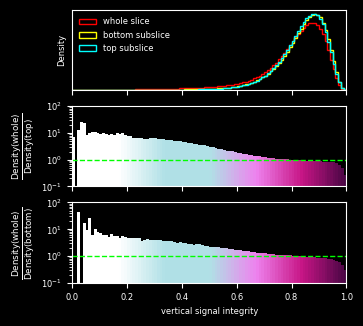

In [55]:
xlim = (0, 1)
kwargs = dict(bins=100, range=xlim, density=True, histtype="step")

with plt.style.context("dark_background"):
    fig, axs = plt.subplots(nrows=3, figsize=(9 * CM, 9 * CM), sharex=True)

    density_sub, bins, _ = axs[0].hist(
        brain_sub.integrity_map[brain_sub.signal_map > t],
        label="whole slice",
        color="red",
        **kwargs,
    )
    density_bottom, *_ = axs[0].hist(
        brain_bottom.integrity_map[brain_bottom.signal_map > t],
        label="bottom subslice",
        color="yellow",
        **kwargs,
    )
    density_top, *_ = axs[0].hist(
        brain_top.integrity_map[brain_top.signal_map > t],
        label="top subslice",
        color="cyan",
        **kwargs,
    )
    _ = axs[0].set(ylabel="Density", yticks=[], xlabel=None, xlim=xlim)
    _ = axs[0].legend(frameon=False)

    # whole/bottom
    hist_quotient = density_sub / density_top
    bars = axs[1].bar(bins[:-1], hist_quotient, width=0.01, align="edge", lw=0)
    for bar, color in zip(bars, cmap(bins[:-1])):
        bar.set_color(color)

    axs[1].set(yscale="log", ylim=(0.1, 100))
    axs[1].set_ylabel(
        r"$\frac{\mathrm{Density(whole)}}{\mathrm{Density(top)}}$", fontsize=9
    )
    axs[1].hlines(1, 0, 1, linestyles="dashed", color="lime", lw=1)

    # whole/top
    hist_quotient = density_sub / density_bottom
    bars = axs[2].bar(bins[:-1], hist_quotient, width=0.01, align="edge", lw=0)
    for bar, color in zip(bars, cmap(bins[:-1])):
        bar.set_color(color)

    axs[2].set(yscale="log", xlabel="vertical signal integrity", ylim=(0.1, 100))
    axs[2].set_ylabel(
        r"$\frac{\mathrm{Density(whole)}}{\mathrm{Density(bottom)}}$", fontsize=9
    )
    axs[2].hlines(1, 0, 1, linestyles="dashed", color="lime", lw=1)

    fig.savefig("integrity_histogram.svg", **save_kwargs)

In [48]:
def plot_doublet(axs, ovrlps, x, y, *, threshold=2, window_size=40):
    for ax, ovrlp in zip(axs, ovrlps):
        _ = plot_vsi(ovrlp, ax, threshold=threshold)
        ax.set_xlim(x - window_size, x + window_size)
        ax.set_ylim(y - window_size, y + window_size)

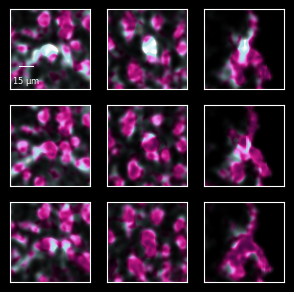

In [49]:
with plt.style.context("dark_background"):
    fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(9 * CM, 9 * CM))
    for i in range(3):
        x, y = doublets["x", "y"].row(i)
        plot_doublet(axs[:, i], [brain_sub, brain_top, brain_bottom], x, y, threshold=t)

    axs[0, 0].add_artist(ScaleBar(**scalebar_kwargs))
    fig.savefig("doublets.svg", **save_kwargs)